In [12]:
import random
import json
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForTokenClassification
from transformers import DataCollatorForTokenClassification, TrainingArguments, Trainer
from peft import LoraConfig, get_peft_model
from sklearn.model_selection import train_test_split

In [43]:
# Define Label Mapping
LABELS = [
    "O",
    "B-ACTION",
    "B-TARGET",
    "B-ATTRIBUTE", "I-ATTRIBUTE",
    "B-DIRECTION",
    "B-ORIENTATION",
    "B-MAGNITUDE", "I-MAGNITUDE",
    "B-REFERENCE", "I-REFERENCE",
    "B-AXIS"
]
LABEL2ID = {label: i for i, label in enumerate(LABELS)}
ID2LABEL = {i: label for label, i in LABEL2ID.items()}

In [14]:
# Template Dataset & Generator
base_commands = [
    (
        "Move the red apple to the right",
        ["Move","the","red","apple","to","the","right"],
        ["B-ACTION","O","B-ATTRIBUTE","B-TARGET","O","O","B-DIRECTION"]
    ),
    (
        "Slide the small chair under the table",
        ["Slide","the","small","chair","under","the","table"],
        ["B-ACTION","O","B-ATTRIBUTE","B-TARGET","O","O","O"]
    ),
    (
        "Rotate the metal box counterclockwise to the left",
        ["Rotate","the","metal","box","counterclockwise","to","the","left"],
        ["B-ACTION","O","B-ATTRIBUTE","B-TARGET","B-ORIENTATION","O","O","B-DIRECTION"]
    ),
    (
        "Push the big cart to the garage",
        ["Push","the","big","cart","to","the","garage"],
        ["B-ACTION","O","B-ATTRIBUTE","B-TARGET","O","O","B-DIRECTION"]
    ),
]

def expand_dataset(n=3000):
    out = []

    actions = [
        "Move","Slide","Lift","Rotate","Push","Pull","Drop","Place",
        "Shift","Put","Turn","Spin",
        "Remove","Delete","Erase",
        "Scale","Resize","Enlarge","Shrink",
        "Change","Recolor","Make"
    ]

    objects = ["ball","box","chair","phone","book","bottle","bag","keys","mouse","toy"]

    colors = ["red","white","blue","green","black","yellow"]
    sizes = ["big","small"]
    materials = ["metal","wooden"]

    directions = ["left","right","up","down","forward","backward"]
    orientations = ["clockwise","counterclockwise","anticlockwise","anti-clockwise"]
    magnitudes = ["slightly","a bit","2m","3 meters","5 units","45 degrees","90 degrees"]
    axes = ["x-axis","y-axis","z-axis"]
    references = ["next to","near","beside","in front of","behind"]

    templates = [
        "{}",
        "please {}",
        "can you {}",
        "try to {}",
        "i want you to {}"
    ]

    for _ in range(n):
        tokens = []
        labels = []

        act = random.choice(actions)
        tokens.append(act.lower())
        labels.append("B-ACTION")

        tokens.append("the")
        labels.append("O")

        # ATTRIBUTES
        attr_tokens = []
        if random.random() < 0.6:
            attr_tokens.append(random.choice(colors))
        if random.random() < 0.3:
            attr_tokens.append(random.choice(sizes))
        if random.random() < 0.2:
            attr_tokens.append(random.choice(materials))

        for i, attr in enumerate(attr_tokens):
            tokens.append(attr)
            labels.append("B-ATTRIBUTE" if i == 0 else "I-ATTRIBUTE")

        # TARGET
        obj = random.choice(objects)
        tokens.append(obj)
        labels.append("B-TARGET")

        # ===== ACTION-SPECIFIC LOGIC ===== #

        # TRANSLATION
        if act.lower() in ["move","slide","shift","push","pull","place","put"]:
            
            # magnitude
            if random.random() < 0.5:
                mag = random.choice(magnitudes).split()
                for i, m in enumerate(mag):
                    tokens.append(m)
                    labels.append("B-MAGNITUDE" if i == 0 else "I-MAGNITUDE")

            # direction
            if random.random() < 0.7:
                tokens += ["to","the"]
                labels += ["O","O"]

                d = random.choice(directions)
                tokens.append(d)
                labels.append("B-DIRECTION")

            # reference-based
            if random.random() < 0.4:
                ref = random.choice(references).split()
                for i, r in enumerate(ref):
                    tokens.append(r)
                    labels.append("B-REFERENCE" if i == 0 else "I-REFERENCE")

                tokens.append("the")
                labels.append("O")

                ref_obj = random.choice(objects)
                tokens.append(ref_obj)
                labels.append("B-TARGET")

        # ROTATION
        if act.lower() in ["rotate","turn","spin"]:
            
            if random.random() < 0.7:
                ori = random.choice(orientations)
                tokens.append(ori)
                labels.append("B-ORIENTATION")

            if random.random() < 0.6:
                mag = random.choice(["45 degrees","90 degrees"]).split()
                for i, m in enumerate(mag):
                    tokens.append(m)
                    labels.append("B-MAGNITUDE" if i == 0 else "I-MAGNITUDE")

            if random.random() < 0.5:
                tokens.append("around")
                labels.append("O")

                axis = random.choice(axes)
                tokens.append(axis)
                labels.append("B-AXIS")

        # SCALE
        if act.lower() in ["scale","resize","enlarge","shrink"]:
            if random.random() < 0.7:
                mag = random.choice(magnitudes).split()
                for i, m in enumerate(mag):
                    tokens.append(m)
                    labels.append("B-MAGNITUDE" if i == 0 else "I-MAGNITUDE")

        # COLOR CHANGE
        if act.lower() in ["change","recolor","make"]:
            tokens.append("to")
            labels.append("O")

            color = random.choice(colors)
            tokens.append(color)
            labels.append("B-ATTRIBUTE")

        # REMOVE → nothing extra

        # ===== NATURAL LANGUAGE WRAP ===== #
        sentence = " ".join(tokens)
        template = random.choice(templates)
        sentence = template.format(sentence)

        out.append((sentence, tokens, labels))

    return out

data = base_commands + expand_dataset(3000)

dataset_dict = {"tokens": [], "labels": []}
for sent, toks, labs in data:
    dataset_dict["tokens"].append(toks)
    # turn tag names into IDs
    dataset_dict["labels"].append([LABEL2ID[l] for l in labs])

# train/test split
train_toks, val_toks, train_labs, val_labs = train_test_split(
    dataset_dict["tokens"], dataset_dict["labels"], test_size=0.1
)

train_ds = Dataset.from_dict({"tokens":train_toks, "labels":train_labs})
val_ds = Dataset.from_dict({"tokens":val_toks, "labels":val_labs})

In [15]:
# Tokenizer & Model
model_name = "bert-base-uncased"  # small, supports token classification
tokenizer = AutoTokenizer.from_pretrained(model_name, add_prefix_space=True)

model = AutoModelForTokenClassification.from_pretrained(
    model_name,
    num_labels=len(LABELS),
    id2label=ID2LABEL,
    label2id=LABEL2ID
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized be

In [16]:
# Tokenize and align labels
def tokenize_and_align(example):
    tokenized = tokenizer(
        example["tokens"],
        truncation=True,
        padding="longest",
        is_split_into_words=True
    )

    labels = []
    previous_word_idx = None

    for word_idx in tokenized.word_ids():
        if word_idx is None:
            labels.append(-100)
        elif word_idx != previous_word_idx:
            labels.append(example["labels"][word_idx])
        else:
            labels.append(-100)
        previous_word_idx = word_idx

    tokenized["labels"] = labels
    return tokenized


train_tkn = train_ds.map(tokenize_and_align, batched=False)
val_tkn = val_ds.map(tokenize_and_align, batched=False)

Map:   0%|          | 0/2703 [00:00<?, ? examples/s]

Map:   0%|          | 0/301 [00:00<?, ? examples/s]

In [17]:
# Lora Config & PEFT
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["query", "key", "value"],
    lora_dropout=0.05,
    bias="none",
    task_type="TOKEN_CLS"
)

model = get_peft_model(model, lora_config)

In [18]:
# Training
data_collator = DataCollatorForTokenClassification(tokenizer)

training_args = TrainingArguments(
    output_dir="token_class_lora",
    eval_strategy="epoch",
    logging_strategy="steps",   
    logging_steps=50,           # log every 50 steps
    learning_rate=5e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=4,
    save_strategy="epoch",
    report_to="none",              # Kaggle-safe
    save_total_limit=1,            # avoid multiple LoRA checkpoints
    load_best_model_at_end=True,   # IMPORTANT
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tkn,
    eval_dataset=val_tkn,
    processing_class=tokenizer,
    data_collator=data_collator,
)

trainer.train()
trainer.save_model("/kaggle/working/token_classifier_lora_model")

/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,2.357467,1.477475
2,0.754525,0.341943
3,0.228060,0.121184
4,0.172927,0.088964


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


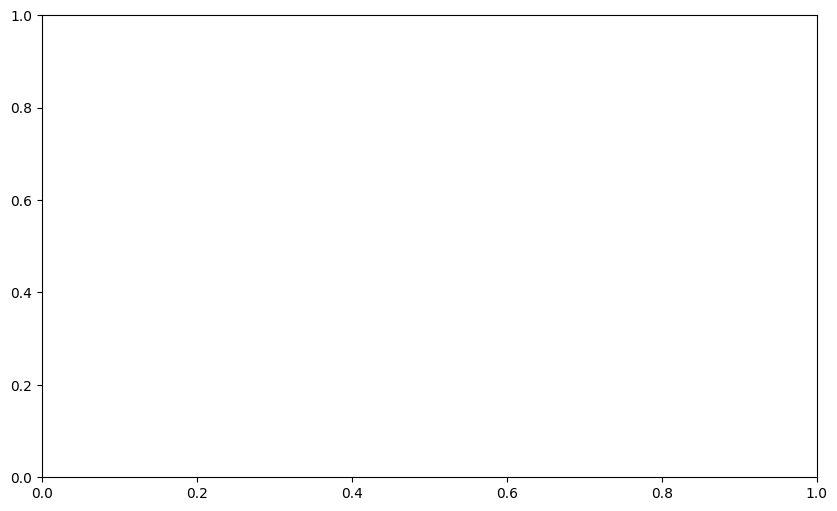

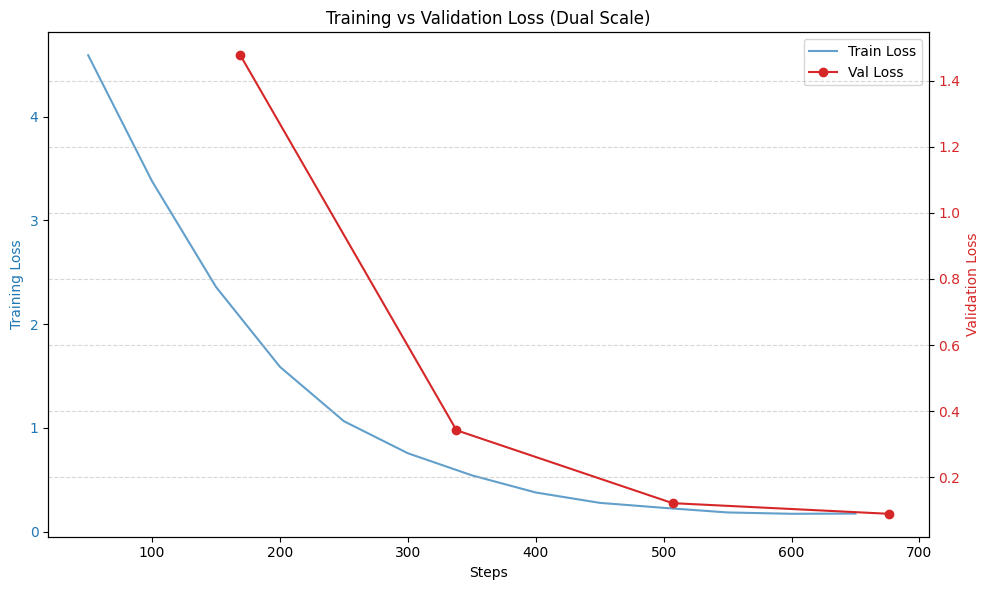

In [19]:
import matplotlib.pyplot as plt

history = trainer.state.log_history

# Filter out Step 0 (the untrained baseline) and extract
train_loss = [log["loss"] for log in history if "loss" in log and log["step"] > 0]
train_steps = [log["step"] for log in history if "loss" in log and log["step"] > 0]

eval_loss = [log["eval_loss"] for log in history if "eval_loss" in log and log["step"] > 0]
eval_steps = [log["step"] for log in history if "eval_loss" in log and log["step"] > 0]

fig, ax1 = plt.subplots(figsize=(10, 6))

import matplotlib.pyplot as plt

# ... (data generation/loading) ...

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Training Loss
color_train = 'tab:blue'
ax1.set_xlabel('Steps')
ax1.set_ylabel('Training Loss', color=color_train)
lns1 = ax1.plot(train_steps, train_loss, color=color_train, label="Train Loss", alpha=0.7)
ax1.tick_params(axis='y', labelcolor=color_train)

# Create second axis for Validation Loss
ax2 = ax1.twinx() 
color_eval = 'tab:red'
ax2.set_ylabel('Validation Loss', color=color_eval)
lns2 = ax2.plot(eval_steps, eval_loss, color=color_eval, label="Val Loss", marker='o')
ax2.tick_params(axis='y', labelcolor=color_eval)

# Combine legends
lns = lns1 + lns2
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper right')

plt.title("Training vs Validation Loss (Dual Scale)")
plt.grid(True, linestyle='--', alpha=0.5)
fig.tight_layout()
plt.savefig('training_validation_loss.png')

In [20]:
print(model.print_trainable_parameters())

trainable params: 451,596 || all params: 109,352,472 || trainable%: 0.4130
None


In [21]:
# Inference has issue as it parses
from transformers import pipeline

nlp = pipeline(
    "token-classification",
    model=model,                 # <-- USE THE PEFT MODEL
    tokenizer=tokenizer,
    aggregation_strategy="simple"
)

nlp("Rotate the box counterclockwise to left")

[{'entity_group': 'ACTION',
  'score': 0.994052,
  'word': 'rotate',
  'start': 0,
  'end': 6},
 {'entity_group': 'TARGET',
  'score': 0.986389,
  'word': 'box',
  'start': 11,
  'end': 14},
 {'entity_group': 'ORIENTATION',
  'score': 0.76986593,
  'word': 'counter',
  'start': 15,
  'end': 22},
 {'entity_group': 'ORIENTATION',
  'score': 0.28515545,
  'word': '##cl',
  'start': 22,
  'end': 24},
 {'entity_group': 'ORIENTATION',
  'score': 0.1887329,
  'word': '##ock',
  'start': 24,
  'end': 27},
 {'entity_group': 'ORIENTATION',
  'score': 0.47371668,
  'word': '##wise',
  'start': 27,
  'end': 31},
 {'entity_group': 'DIRECTION',
  'score': 0.77087873,
  'word': 'left',
  'start': 35,
  'end': 39}]

In [22]:
from transformers import pipeline

# 1) Set up pipeline with no aggregation (raw token outputs)
nlp = pipeline(
    "token-classification",
    model=model,            # Your trained PEFT model
    tokenizer=tokenizer,
    aggregation_strategy=None  # Raw tokens + subword info
)

def merge_subwords(token_outputs):
    merged = []
    current_word = ""
    current_label = None
    current_score = 0.0
    count = 0

    for t in token_outputs:
        # Get the correct label key
        label = t.get("entity") or t.get("entity_group")
        word = t["word"]

        if word.startswith("##"):
            # Accumulate subword piece
            current_word += word[2:]
            current_score += t["score"]
            count += 1
        else:
            # Save previous word (if any)
            if current_word:
                merged.append({
                    "word": current_word,
                    "entity_group": current_label,
                    "score": current_score / count
                })
            # Start a new word
            current_word = word
            current_label = label
            current_score = t["score"]
            count = 1

    # Append the last word
    if current_word:
        merged.append({
            "word": current_word,
            "entity_group": current_label,
            "score": current_score / count
        })

    return merged

# Example inference
sentence = "Rotate the box counterclockwise to left"
token_outputs = nlp(sentence)
clean_tokens = merge_subwords(token_outputs)

clean_tokens

[{'word': 'rotate', 'entity_group': 'B-ACTION', 'score': 0.994051992893219},
 {'word': 'box', 'entity_group': 'B-TARGET', 'score': 0.9863889813423157},
 {'word': 'counterclockwise',
  'entity_group': 'B-ORIENTATION',
  'score': 0.42936772108078003},
 {'word': 'left', 'entity_group': 'B-DIRECTION', 'score': 0.7708787322044373}]

In [23]:
!zip -r /kaggle/working/lora_model_1.zip /kaggle/working/token_classifier_lora_model

  adding: kaggle/working/token_classifier_lora_model/ (stored 0%)
  adding: kaggle/working/token_classifier_lora_model/training_args.bin (deflated 52%)
  adding: kaggle/working/token_classifier_lora_model/tokenizer_config.json (deflated 43%)
  adding: kaggle/working/token_classifier_lora_model/README.md (deflated 66%)
  adding: kaggle/working/token_classifier_lora_model/tokenizer.json (deflated 71%)
  adding: kaggle/working/token_classifier_lora_model/adapter_config.json (deflated 57%)
  adding: kaggle/working/token_classifier_lora_model/adapter_model.safetensors (deflated 7%)


In [24]:
pip install -U peft

Note: you may need to restart the kernel to use updated packages.


In [55]:
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline
from peft import PeftModel

BASE_MODEL = "bert-base-uncased"


# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Recreate base model EXACTLY like training
base_model = AutoModelForTokenClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(LABELS),
    id2label=ID2LABEL,
    label2id=LABEL2ID
)

# Load LoRA adapter
model = PeftModel.from_pretrained(
    base_model,
    "/kaggle/input/models/abhijeetkc/lora-model-final/other/default/1/kaggle/working/token_classifier_lora_model"
)

model.eval()

# Token classification pipeline
nlp = pipeline(
    "token-classification",
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy="simple"
)

# Test
nlp("Rotate the red box counterclockwise to the left")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized be

[{'entity_group': 'ACTION',
  'score': 0.9939162,
  'word': 'rotate',
  'start': 0,
  'end': 6},
 {'entity_group': 'ATTRIBUTE',
  'score': 0.9905427,
  'word': 'red',
  'start': 11,
  'end': 14},
 {'entity_group': 'TARGET',
  'score': 0.99127287,
  'word': 'box',
  'start': 15,
  'end': 18},
 {'entity_group': 'ORIENTATION',
  'score': 0.74928397,
  'word': 'counter',
  'start': 19,
  'end': 26},
 {'entity_group': 'ORIENTATION',
  'score': 0.29220292,
  'word': '##cl',
  'start': 26,
  'end': 28},
 {'entity_group': 'ORIENTATION',
  'score': 0.18329637,
  'word': '##ock',
  'start': 28,
  'end': 31},
 {'entity_group': 'ORIENTATION',
  'score': 0.43149954,
  'word': '##wise',
  'start': 31,
  'end': 35},
 {'entity_group': 'DIRECTION',
  'score': 0.9270472,
  'word': 'left',
  'start': 43,
  'end': 47}]

In [46]:
from peft import PeftConfig
config = PeftConfig.from_pretrained("/kaggle/working/token_classifier_lora_model")
config

LoraConfig(task_type='TOKEN_CLS', peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, peft_version='0.18.1', base_model_name_or_path='bert-base-uncased', revision=None, inference_mode=True, r=8, target_modules={'query', 'key', 'value'}, exclude_modules=None, lora_alpha=16, lora_dropout=0.05, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=['classifier', 'score'], init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, use_dora=False, alora_invocation_tokens=None, use_qalora=False, qalora_group_size=16, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False), lora_bias=False, target_parameters=None, arrow_config=None, ensure_weight_tying=False)

In [47]:
nlp("Rotate the red box clockwise to the left")

[{'entity_group': 'ACTION',
  'score': 0.99441576,
  'word': 'rotate',
  'start': 0,
  'end': 6},
 {'entity_group': 'ATTRIBUTE',
  'score': 0.9899464,
  'word': 'red',
  'start': 11,
  'end': 14},
 {'entity_group': 'TARGET',
  'score': 0.99142516,
  'word': 'box',
  'start': 15,
  'end': 18},
 {'entity_group': 'ORIENTATION',
  'score': 0.5901209,
  'word': 'clockwise',
  'start': 19,
  'end': 28},
 {'entity_group': 'DIRECTION',
  'score': 0.9264805,
  'word': 'left',
  'start': 36,
  'end': 40}]

In [48]:
model.config.num_labels

12

In [49]:
test_x = "Rotate this bottle clockwise"
test_x_nlp = nlp(test_x)
merged = merge_subwords(test_x_nlp)

In [50]:
print(test_x_nlp)
merged

[{'entity_group': 'ACTION', 'score': 0.9933274, 'word': 'rotate', 'start': 0, 'end': 6}, {'entity_group': 'TARGET', 'score': 0.9834579, 'word': 'bottle', 'start': 12, 'end': 18}, {'entity_group': 'ORIENTATION', 'score': 0.57794935, 'word': 'clockwise', 'start': 19, 'end': 28}]


[{'word': 'rotate', 'entity_group': 'ACTION', 'score': 0.9933273792266846},
 {'word': 'bottle', 'entity_group': 'TARGET', 'score': 0.9834579229354858},
 {'word': 'clockwise',
  'entity_group': 'ORIENTATION',
  'score': 0.5779493451118469}]

In [51]:
prompt = nlp("Remove the flower vase")
prompt

[{'entity_group': 'ACTION',
  'score': 0.9942654,
  'word': 'remove',
  'start': 0,
  'end': 6},
 {'entity_group': 'ATTRIBUTE',
  'score': 0.8477192,
  'word': 'flower',
  'start': 11,
  'end': 17},
 {'entity_group': 'TARGET',
  'score': 0.9877473,
  'word': 'vase',
  'start': 18,
  'end': 22}]